# Imports


In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForMaskedLM
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# Constants

FRACTION_SAMPLE = 0.5  # Use a fraction of the data for faster experimentation
RANDOM_STATE = 42

In [3]:
# Model and Tokenizer
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [ ]:
# prompts and word lists for humor prediction
prompt_dezimal = "On a scale from 0.0 to 1.0 this review is 0.[MASK] funny."
funny_words_dezimal = ["5", "6", "7", "8", "9", "10"]
not_funny_words_dezimal = [
    "0",
    "1",
    "2",
    "3",
    "4",
]

prompt_int = "On a scale from 0 to 10 this review is [MASK] funny."
funny_words_int = ["5", "6", "7", "8", "9"]
not_funny_words_int = ["0", "1", "2", "3", "4"]

prompt1 = "This review is [MASK]."
funny_words1 = ["funny", "hilarious", "humorous", "witty", "comedic", "amusing"]
not_funny_words1 = ["boring", "serious", "normal", "ordinary", "dull", "generic"]

prompt2 = "This review is meant to be [MASK]."

prompt3 = "Most people would find this review [MASK]."

prompt4 = "The author wrote this to be [MASK]."

prompt5 = "The writer was trying to be [MASK]."

prompt6 = "This was written in a [MASK] way."

prompt7 = "This review is [MASK] funny."
funny_words7 = [
    "slightly",
    "very",
    "totally",
    "extremely",
    "incredibly",
    "absolutely",
    "genuinely",
    "truly",
    "remarkably",
    "really",
    "pretty",
    "so",
    "quite",
    "rather",
]
not_funny_words7 = [
    "somewhat",
    "barely",
    "hardly",
    "mildly",
    "not",
    "scarcely",
    "almost",
]

serious ['serious'] 1
witty ['witty'] 1
amusing ['amusing'] 1
hilarious ['hilarious'] 1
hysterical ['hysterical'] 1


# Dataset

Load and sample the dataset


In [ ]:
# Load data
df = pd.read_csv("./data/preprocessed/steam_reviews_preprocessed.csv")

In [ ]:
# Token length analysis for reviews and prompts
tqdm.pandas()

# Review lengths
df["review_char_len"] = df["review_text_cleaned"].astype(str).str.len()
df["review_token_len"] = (
    df["review_text_cleaned"]
    .astype(str)
    .progress_apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))
)

# Prompt lengths (use prompts defined below)
prompts = {
    "prompt_dezimal": prompt_dezimal,
    "prompt_int": prompt_int,
    "prompt1": prompt1,
    "prompt2": prompt2,
    "prompt3": prompt3,
    "prompt4": prompt4,
    "prompt5": prompt5,
    "prompt6": prompt6,
    "prompt7": prompt7,
}

prompt_stats = []
for name, text in prompts.items():
    prompt_tokens = len(tokenizer.encode(text, add_special_tokens=False))
    max_review_tokens = 512 - prompt_tokens - 2  # [CLS] + [SEP]
    exceed_count = (df["review_token_len"] > max_review_tokens).sum()
    prompt_stats.append(
        {
            "prompt": name,
            "prompt_token_len": prompt_tokens,
            "max_review_tokens": max_review_tokens,
            "exceed_count": exceed_count,
            "exceed_pct": exceed_count / len(df),
        }
    )

prompt_stats_df = pd.DataFrame(prompt_stats).sort_values(
    "prompt_token_len", ascending=False
)

print("=== Review length summary ===")
print(
    df[["review_char_len", "review_token_len"]]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .T
)

print("\n=== Prompt token lengths and truncation impact ===")
print(prompt_stats_df.to_string(index=False))

  0%|          | 0/715901 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (738 > 512). Running this sequence through the model will result in indexing errors


=== Review length summary ===
                     count        mean         std  min   50%    90%     95%  \
review_char_len   715901.0  240.242433  540.824854  1.0  73.0  574.0  1010.0   
review_token_len  715901.0   55.897448  127.147015  0.0  18.0  131.0   231.0   

                     99%     max  
review_char_len   2638.0  8000.0  
review_token_len   606.0  7988.0  

=== Prompt token lengths and truncation impact ===
        prompt  prompt_token_len  max_review_tokens  exceed_count  exceed_pct
prompt_dezimal                19                491         10867    0.015179
    prompt_int                13                497         10512    0.014684
       prompt2                 8                502         10317    0.014411
       prompt3                 8                502         10317    0.014411
       prompt4                 8                502         10317    0.014411
       prompt6                 8                502         10317    0.014411
       prompt5            

In [7]:
# Drop reviews that exceed token length when combined with prompt_dezimal
# prompt_dezimal has 17 tokens, leaving 493 tokens for review (512 - 17 - 2 for [CLS] and [SEP])
max_tokens_for_dezimal = 490
df = df[df["review_token_len"] <= max_tokens_for_dezimal].reset_index(drop=True)
print(f"Dropped reviews exceeding token limit. Remaining reviews: {len(df):,}")

Dropped reviews exceeding token limit. Remaining reviews: 704,992


In [ ]:
# Use a balanced sample: Same amount of funny and not-funny reviews for better evaluation of the model's ability to distinguish humor
funny_df = df[df["label_is_funny_binary"] == 1].sample(
    frac=FRACTION_SAMPLE, random_state=RANDOM_STATE
)
not_funny_df = df[df["label_is_funny_binary"] == 0].sample(
    n=len(funny_df), random_state=RANDOM_STATE
)
sample = (
    pd.concat([funny_df, not_funny_df])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(
    f"Sample size: {len(sample):,}  |  Funny: {sample['label_is_funny_binary'].sum():,}  |  Not Funny: {(sample['label_is_funny_binary'] == 0).sum():,}"
)

Sample size: 3,396  |  Funny: 1,698  |  Not Funny: 1,698


# Predictions


## Single-Review Spot Check

Run a single prediction for three representative reviews:

1. The review with the **highest** `review_votes_funny`
2. A review with an **average** (median) `review_votes_funny`
3. A review with **zero** `review_votes_funny`


In [ ]:
def predict_single_review(
    row,
    prompt,
    tokenizer,
    model,
    device,
    funny_words,
    not_funny_words,
    top_k=10,
    max_length=512,
):
    """Run a masked-LM prediction for a single review and print detailed results."""
    target_words = funny_words + not_funny_words
    target_ids = {w: tokenizer.convert_tokens_to_ids(w) for w in target_words}
    mask_id = tokenizer.mask_token_id

    prompt_token_count = len(tokenizer.encode(prompt, add_special_tokens=False))
    max_review_tokens = max_length - prompt_token_count - 2

    text = row["review_text_cleaned"]
    review_ids = tokenizer.encode(text, add_special_tokens=False)[:max_review_tokens]
    review_text = tokenizer.decode(review_ids, skip_special_tokens=True)
    combined = f"{review_text} {prompt}"

    inputs = tokenizer(
        combined, return_tensors="pt", truncation=True, max_length=max_length
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits.squeeze(0)

    mask_pos = (
        (inputs["input_ids"].squeeze(0) == mask_id).nonzero(as_tuple=False).item()
    )
    probs = torch.softmax(logits[mask_pos], dim=-1)

    top_probs, top_indices = probs.topk(top_k)
    top_tokens = tokenizer.convert_ids_to_tokens(top_indices.cpu().tolist())
    top_k_list = list(zip(top_tokens, [round(p, 6) for p in top_probs.cpu().tolist()]))

    target_scores = {w: round(probs[tid].item(), 6) for w, tid in target_ids.items()}
    funny_sum = sum(target_scores[w] for w in funny_words)
    not_funny_sum = sum(target_scores[w] for w in not_funny_words)

    return {
        "top_k": top_k_list,
        "target_scores": target_scores,
        "funny_sum": round(funny_sum, 6),
        "not_funny_sum": round(not_funny_sum, 6),
    }


def spot_check_reviews(
    sample, prompt, tokenizer, model, device, funny_words, not_funny_words
):
    """Pick three representative reviews and run predictions on each."""

    # Filter to keep only single-token words
    discarded_funny = [
        w
        for w in funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) != 1
    ]
    discarded_not_funny = [
        w
        for w in not_funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) != 1
    ]

    if discarded_funny or discarded_not_funny:
        print(
            f"Discarded multi-token words - Funny: {discarded_funny}, Not Funny: {discarded_not_funny}"
        )

    funny_words = [
        w
        for w in funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) == 1
    ]
    not_funny_words = [
        w
        for w in not_funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) == 1
    ]

    # 1. Highest funny votes
    row_max = sample.loc[sample["review_votes_funny"].idxmax()]

    # 2. Median funny votes (closest to median)
    median_votes = sample["review_votes_funny"].median()
    row_med = sample.iloc[
        (sample["review_votes_funny"] - median_votes).abs().argsort().iloc[0]
    ]

    # 3. Zero funny votes (random pick)
    zero_df = sample[sample["review_votes_funny"] == 0]
    row_zero = zero_df.sample(n=1, random_state=RANDOM_STATE).iloc[0]

    picks = [
        ("HIGHEST funny votes", row_max),
        ("MEDIAN funny votes", row_med),
        ("ZERO funny votes", row_zero),
    ]

    print(f'Prompt: "{prompt}"\n')
    for label, row in picks:
        result = predict_single_review(
            row, prompt, tokenizer, model, device, funny_words, not_funny_words
        )
        print(f"=== {label} ===")
        print(f"  Review ID : {row['review_id']}")
        print(f"  Game      : {row['app_name']}")
        print(
            f"  Funny Votes: {row['review_votes_funny']}  |  Label: {'Funny' if row['label_is_funny_binary'] == 1 else 'Not Funny'}"
        )
        print(f"  Text      : {row['review_text_cleaned']}")
        print(f"  Top-{len(result['top_k'])}: {result['top_k']}")

        funny_str = ", ".join(
            f"{w}: {result['target_scores'][w]}"
            for w in sorted(
                funny_words, key=lambda w: result["target_scores"][w], reverse=True
            )
        )
        not_funny_str = ", ".join(
            f"{w}: {result['target_scores'][w]}"
            for w in sorted(
                not_funny_words, key=lambda w: result["target_scores"][w], reverse=True
            )
        )
        print()
        print(f"  Funny     : {{{funny_str}}}  SUM={result['funny_sum']}")
        print(f"  Not Funny : {{{not_funny_str}}}  SUM={result['not_funny_sum']}")

### Masked-token prediction for “funny vs not funny” word sets (batched)

`get_mask_predictions(...)` runs a masked-language model over a list of review texts by appending a `prompt` that **must contain `[MASK]`**. For each review, it finds the `[MASK]` position and:

- returns the **top-k predicted tokens** at the mask with their probabilities
- extracts probabilities for a **target vocabulary** (`funny_words + not_funny_words`)
- computes aggregate scores: `funny_sum` and `not_funny_sum` (sums of the respective target-word probabilities)

The function **pre-truncates** reviews so the prompt (and `[MASK]`) is never truncated, and processes inputs in **GPU-friendly batches**. It also prints a small debug preview (first 5 funny / not-funny examples from `sample`) before returning a list of per-text result dicts.


In [ ]:
def get_mask_predictions(
    texts,
    prompt,
    tokenizer,
    model,
    device,
    funny_words,
    not_funny_words,
    top_k=10,
    max_length=512,
    batch_size=32,
):
    """
    For each review, append `prompt` (which must contain [MASK]),
    then return the top-k predicted words at the [MASK] position
    and the probabilities for every word in TARGET_WORDS.

    Processes texts in batches for faster GPU execution.

    Returns a list of dicts, one per text:
        {
            "top_k": [(word, prob), ...],          # top-k predictions
            "target_scores": {word: prob, ...},     # scores for TARGET_WORDS
            "funny_sum": float,                     # sum of funny word probs
            "not_funny_sum": float,                 # sum of not-funny word probs
        }
    """

    # Filter to keep only single-token words
    discarded_funny = [
        w
        for w in funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) != 1
    ]
    discarded_not_funny = [
        w
        for w in not_funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) != 1
    ]

    if discarded_funny or discarded_not_funny:
        print(
            f"Discarded multi-token words - Funny: {discarded_funny}, Not Funny: {discarded_not_funny}"
        )

    funny_words = [
        w
        for w in funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) == 1
    ]
    not_funny_words = [
        w
        for w in not_funny_words
        if len(tokenizer.encode(w, add_special_tokens=False)) == 1
    ]

    target_words = funny_words + not_funny_words
    target_ids = {w: tokenizer.convert_tokens_to_ids(w) for w in target_words}
    target_id_tensor = torch.tensor(
        [target_ids[w] for w in target_words], device=device
    )
    mask_id = tokenizer.mask_token_id

    # Reserve tokens for: [CLS] + prompt tokens + [SEP]
    prompt_token_count = len(tokenizer.encode(prompt, add_special_tokens=False))
    max_review_tokens = max_length - prompt_token_count - 2

    # Pre-truncate all reviews so the prompt (with [MASK]) is never cut off
    combined_texts = []
    for text in texts:
        review_ids = tokenizer.encode(text, add_special_tokens=False)[
            :max_review_tokens
        ]
        review_text = tokenizer.decode(review_ids, skip_special_tokens=True)
        combined_texts.append(f"{review_text} {prompt}")

    results = []
    num_batches = (len(combined_texts) + batch_size - 1) // batch_size

    for batch_idx in tqdm(range(num_batches), desc="Predicting (batched)"):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(combined_texts))
        batch_texts = combined_texts[start:end]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding=True,
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits  # (batch, seq_len, vocab)

        input_ids = inputs["input_ids"]  # (batch, seq_len)

        # Find [MASK] positions for each item in the batch
        mask_positions = (input_ids == mask_id).nonzero(
            as_tuple=False
        )  # (N, 2) -> [batch_idx, seq_pos]

        for i in range(len(batch_texts)):
            # Get the mask position for this item
            item_masks = mask_positions[mask_positions[:, 0] == i]
            mask_pos = item_masks[0, 1].item()

            probs = torch.softmax(logits[i, mask_pos], dim=-1)

            # Top-k predictions
            top_probs, top_indices = probs.topk(top_k)
            top_tokens = tokenizer.convert_ids_to_tokens(top_indices.cpu().tolist())
            top_k_list = list(
                zip(top_tokens, [round(p, 6) for p in top_probs.cpu().tolist()])
            )

            # Target-word scores (vectorized lookup)
            target_probs = probs[target_id_tensor].cpu().tolist()
            target_scores = {w: round(p, 6) for w, p in zip(target_words, target_probs)}

            funny_sum = sum(target_scores[w] for w in funny_words)
            not_funny_sum = sum(target_scores[w] for w in not_funny_words)

            results.append(
                {
                    "top_k": top_k_list,
                    "target_scores": target_scores,
                    "funny_sum": round(funny_sum, 6),
                    "not_funny_sum": round(not_funny_sum, 6),
                }
            )

    print(f"\nResults: {len(results)}")

    # Print first 5 funny reviews
    funny_indices = sample[sample["label_is_funny_binary"] == 1].index[:2]
    print("=== FUNNY REVIEWS ===\n")
    for idx in funny_indices:
        i = sample.index.get_loc(idx)
        label_binary = (
            "Funny" if sample["label_is_funny_binary"].iloc[i] == 1 else "Not Funny"
        )
        label_minmax = sample["label_funny_minmax"].iloc[i]
        print(
            f"--- Review {sample['review_id'].iloc[i]} Game: {sample['app_name'].iloc[i]} ---"
        )
        print(
            f"Funny Votes: {sample['review_votes_funny'].iloc[i]} --- label: [{label_binary}, {label_minmax}]"
        )
        print(f"Text: {sample['review_text_cleaned'].iloc[i]}")
        print(f"Top-5: {results[i]['top_k']}")
        funny_scores = sorted(
            ((w, results[i]["target_scores"][w]) for w in funny_words),
            key=lambda x: x[1],
            reverse=True,
        )
        funny_scores_str = ", ".join([f"{w}: {score}" for w, score in funny_scores])
        print(f"Funny:     {{{funny_scores_str}}}  SUM={results[i]['funny_sum']}")

        not_funny_scores = sorted(
            ((w, results[i]["target_scores"][w]) for w in not_funny_words),
            key=lambda x: x[1],
            reverse=True,
        )
        not_funny_scores_str = ", ".join(
            [f"{w}: {score}" for w, score in not_funny_scores]
        )
        print(
            f"Not Funny: {{{not_funny_scores_str}}}  SUM={results[i]['not_funny_sum']}"
        )

    # Print first 5 not funny reviews
    not_funny_indices = sample[sample["label_is_funny_binary"] == 0].index[:2]
    print("\n=== NOT FUNNY REVIEWS ===\n")
    for idx in not_funny_indices:
        i = sample.index.get_loc(idx)
        label_binary = (
            "Funny" if sample["label_is_funny_binary"].iloc[i] == 1 else "Not Funny"
        )
        label_minmax = sample["label_funny_minmax"].iloc[i]
        print(
            f"--- Review {sample['review_id'].iloc[i]} Game: {sample['app_name'].iloc[i]} ---"
        )
        print(
            f"Funny Votes: {sample['review_votes_funny'].iloc[i]} --- label: [{label_binary}, {label_minmax}]"
        )
        print(f"Text: {sample['review_text_cleaned'].iloc[i]}")
        print(f"Top-5: {results[i]['top_k']}")

        funny_scores = sorted(
            ((w, results[i]["target_scores"][w]) for w in funny_words),
            key=lambda x: x[1],
            reverse=True,
        )
        funny_scores_str = ", ".join([f"{w}: {score}" for w, score in funny_scores])
        print(f"Funny:     {{{funny_scores_str}}}  SUM={results[i]['funny_sum']}")

        not_funny_scores = sorted(
            ((w, results[i]["target_scores"][w]) for w in not_funny_words),
            key=lambda x: x[1],
            reverse=True,
        )
        not_funny_scores_str = ", ".join(
            [f"{w}: {score}" for w, score in not_funny_scores]
        )

    return results

In [ ]:
texts = sample["review_text_cleaned"].tolist()

### Prompt: "On a scale from 0.0 to 1.0 this review is [MASK] funny."


In [ ]:
results_dezimal = get_mask_predictions(
    texts,
    prompt_dezimal,
    tokenizer,
    model,
    device,
    funny_words_dezimal,
    not_funny_words_dezimal,
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('5', 0.343879), ('8', 0.128086), ('9', 0.095299), ('6', 0.088978), ('1', 0.044056), ('2', 0.030645), ('10', 0.029516), ('4', 0.024864), ('25', 0.021101), ('7', 0.018807)]
Funny:     {5: 0.343879, 8: 0.128086, 9: 0.095299, 6: 0.088978, 7: 0.018807}  SUM=0.675049
Not Funny: {1: 0.044056, 2: 0.030645, 4: 0.024864, 0: 0.018366, 3: 0.014891}  SUM=0.132822
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('5', 0.268747), ('8', 0.135437), ('9', 0.115233), ('6', 0.109693), ('2', 0.035465), ('1', 0.033113), ('25', 0.02716), ('10', 0.026815), ('4', 0.026169), ('7', 0.021043)]
Funny:     {5: 0.268747, 8: 0.135437, 9: 0.115233, 6: 0.109693, 7: 0.021043}  SUM=0.650153
Not Funny: {2: 0.035465, 1: 0.033113, 4: 0.026169, 0: 0.02098, 3: 0.015769}  

In [ ]:
spot_check_reviews(
    sample,
    prompt_dezimal,
    tokenizer,
    model,
    device,
    funny_words_dezimal,
    not_funny_words_dezimal,
)

Prompt: "On a scale from 0.0 to 1.0 this review is 0.[MASK] funny."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('5', 0.246179), ('9', 0.122851), ('0', 0.111524), ('8', 0.107077), ('6', 0.084014), ('1', 0.051746), ('2', 0.050021), ('7', 0.033042), ('4', 0.030488), ('3', 0.023602)]

  Funny     : {5: 0.246179, 9: 0.122851, 8: 0.107077, 6: 0.084014, 7: 0.033042}  SUM=0.593163
  Not Funny : {0: 0.111524, 1: 0.051746, 2: 0.050021, 4: 0.030488, 3: 0.023602}  SUM=0.267381
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not fix the crashing issues on Jedah. However, after disabling RTX, it remained stable enough to play. There is a memory

### Prompt: "On a scale from 0 to 10 this review is [MASK] funny."


In [ ]:
results_int = get_mask_predictions(
    texts, prompt_int, tokenizer, model, device, funny_words_int, not_funny_words_int
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('very', 0.259996), ('not', 0.109765), ('pretty', 0.06654), ('quite', 0.063374), ('really', 0.040603), ('extremely', 0.038748), ('rather', 0.028835), ('just', 0.019914), ('so', 0.019649), ('fairly', 0.018759)]
Funny:     {5: 8e-06, 7: 5e-06, 9: 4e-06, 6: 3e-06, 8: 3e-06}  SUM=2.3e-05
Not Funny: {2: 8e-06, 1: 5e-06, 4: 3e-06, 3: 2e-06, 0: 1e-06}  SUM=1.9e-05
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('not', 0.258456), ('very', 0.169116), ('pretty', 0.062636), ('quite', 0.045699), ('really', 0.037073), ('rather', 0.035738), ('just', 0.028155), ('extremely', 0.025451), ('so', 0.018205), ('fairly', 0.015387)]
Funny:     {5: 5e-06, 7: 3e-06, 6: 2e-06, 8: 2e-06, 9: 2e-06}  SUM=1.4e-05
Not Funny: {2: 7e-06, 1: 5e-06, 4: 3e-06, 0: 2e

In [ ]:
spot_check_reviews(
    sample, prompt_int, tokenizer, model, device, funny_words_int, not_funny_words_int
)

Prompt: "On a scale from 0 to 10 this review is [MASK] funny."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('pretty', 0.207074), ('very', 0.19131), ('quite', 0.110594), ('not', 0.088168), ('really', 0.051617), ('rather', 0.031517), ('almost', 0.024089), ('so', 0.023218), ('extremely', 0.022015), ('just', 0.02029)]

  Funny     : {5: 2e-06, 6: 1e-06, 7: 1e-06, 8: 1e-06, 9: 1e-06}  SUM=6e-06
  Not Funny : {2: 3e-06, 1: 2e-06, 0: 1e-06, 3: 1e-06, 4: 1e-06}  SUM=8e-06
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not fix the crashing issues on Jedah. However, after disabling RTX, it remained stable enough to play. There is a memory l

### Prompt: "This review is [MASK]"

A prompt where various words could fit the mask. Not just such classifing the prompt as funny or not funny


In [ ]:
results_p1 = get_mask_predictions(
    texts, prompt1, tokenizer, model, device, funny_words1, not_funny_words1
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('positive', 0.747918), ('mixed', 0.084237), ('favorable', 0.036954), ('negative', 0.027642), ('good', 0.010077), ('average', 0.009273), ('excellent', 0.00916), ('recommended', 0.005953), ('poor', 0.005288), ('enthusiastic', 0.002918)]
Funny:     {humorous: 8.1e-05, funny: 1.2e-05, amusing: 1.1e-05, witty: 5e-06, hilarious: 2e-06, comedic: 1e-06}  SUM=0.000112
Not Funny: {normal: 8e-05, dull: 6.8e-05, boring: 4.2e-05, generic: 1.1e-05, ordinary: 7e-06, serious: 4e-06}  SUM=0.000212
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('positive', 0.254771), ('good', 0.10322), ('true', 0.035758), ('accurate', 0.032358), ('negative', 0.032212), ('bad', 0.016741), ('favorable', 0.013537), ('interesting', 0.011588), ('complete', 0.01122), (

In [ ]:
spot_check_reviews(
    sample, prompt1, tokenizer, model, device, funny_words1, not_funny_words1
)

Prompt: "This review is [MASK]."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('over', 0.135816), ('good', 0.042397), ('done', 0.03097), ('important', 0.023698), ('finished', 0.022316), ('interesting', 0.01885), ('wonderful', 0.018593), ('excellent', 0.017355), ('great', 0.017199), ('complete', 0.014802)]

  Funny     : {funny: 0.00471, hilarious: 0.002258, amusing: 0.001546, humorous: 9.5e-05, witty: 4e-05, comedic: 3e-06}  SUM=0.008652
  Not Funny : {boring: 0.00726, serious: 0.004675, dull: 0.000314, normal: 0.000224, ordinary: 4e-05, generic: 2e-05}  SUM=0.012533
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not fix the crashi

### Prompt: "This review is meant to be [MASK]."


In [ ]:
results_p2 = get_mask_predictions(
    texts, prompt2, tokenizer, model, device, funny_words1, not_funny_words1
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('positive', 0.148505), ('free', 0.093889), ('pg', 0.027912), ('interesting', 0.021393), ('short', 0.021036), ('humorous', 0.017994), ('independent', 0.01428), ('entertaining', 0.014274), ('retrospective', 0.01261), ('good', 0.011183)]
Funny:     {humorous: 0.017994, funny: 0.000914, amusing: 0.000643, witty: 0.000531, comedic: 0.000499, hilarious: 5e-05}  SUM=0.020631
Not Funny: {serious: 0.003494, boring: 0.001012, dull: 0.000198, generic: 0.000195, normal: 0.000188, ordinary: 6.1e-05}  SUM=0.005148
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('humorous', 0.046074), ('positive', 0.045003), ('published', 0.033479), ('interesting', 0.028066), ('funny', 0.024662), ('read', 0.022273), ('good', 0.022232), ('free', 0.020731), ('wri

In [ ]:
spot_check_reviews(
    sample, prompt2, tokenizer, model, device, funny_words1, not_funny_words1
)

Prompt: "This review is meant to be [MASK]."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('fun', 0.075445), ('interesting', 0.061391), ('good', 0.0533), ('funny', 0.044004), ('free', 0.032106), ('entertaining', 0.028227), ('short', 0.015621), ('done', 0.011633), ('yours', 0.010535), ('amusing', 0.010244)]

  Funny     : {funny: 0.044004, amusing: 0.010244, humorous: 0.004966, hilarious: 0.00088, witty: 0.000397, comedic: 0.000121}  SUM=0.060612
  Not Funny : {serious: 0.005589, boring: 0.003088, dull: 0.001109, normal: 0.00019, ordinary: 0.00012, generic: 1.7e-05}  SUM=0.010113
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not fi

### Prompt: "Most people would find this review [MASK]."


In [ ]:
results_p3 = get_mask_predictions(
    texts, prompt3, tokenizer, model, device, funny_words1, not_funny_words1
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('interesting', 0.131675), ('boring', 0.121594), ('entertaining', 0.06065), ('disappointing', 0.026609), ('unfair', 0.025641), ('funny', 0.02349), ('amusing', 0.020637), ('fascinating', 0.018151), ('annoying', 0.017022), ('odd', 0.016754)]
Funny:     {funny: 0.02349, amusing: 0.020637, humorous: 0.012709, hilarious: 0.005307, witty: 0.000338, comedic: 1.8e-05}  SUM=0.062499
Not Funny: {boring: 0.121594, dull: 0.005837, normal: 0.000118, serious: 8.5e-05, generic: 3.8e-05, ordinary: 2.7e-05}  SUM=0.127699
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('boring', 0.153681), ('interesting', 0.101578), ('entertaining', 0.096236), ('amusing', 0.065736), ('funny', 0.063441), ('fascinating', 0.023171), ('humorous', 0.018294), ('ridiculou

In [ ]:
spot_check_reviews(
    sample, prompt3, tokenizer, model, device, funny_words1, not_funny_words1
)

Prompt: "Most people would find this review [MASK]."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('boring', 0.205124), ('interesting', 0.109706), ('amusing', 0.092661), ('fascinating', 0.053297), ('funny', 0.044964), ('entertaining', 0.036408), ('hilarious', 0.027399), ('disturbing', 0.022834), ('ridiculous', 0.019572), ('odd', 0.019521)]

  Funny     : {amusing: 0.092661, funny: 0.044964, hilarious: 0.027399, humorous: 0.007525, witty: 9.2e-05, comedic: 9e-06}  SUM=0.17265
  Not Funny : {boring: 0.205124, dull: 0.006139, serious: 0.00012, normal: 4.6e-05, generic: 1.8e-05, ordinary: 9e-06}  SUM=0.211456
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounti

### Prompt: "The author wrote this to be [MASK]."


In [ ]:
results_p4 = get_mask_predictions(
    texts, prompt4, tokenizer, model, device, funny_words1, not_funny_words1
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('true', 0.255904), ('accurate', 0.027575), ('sure', 0.019762), ('interesting', 0.018572), ('correct', 0.014719), ('perfect', 0.01442), ('easy', 0.013313), ('clear', 0.012343), ('precise', 0.012001), ('good', 0.011236)]
Funny:     {amusing: 0.002596, humorous: 0.001421, funny: 0.001362, witty: 0.000167, hilarious: 9.3e-05, comedic: 1.7e-05}  SUM=0.005656
Not Funny: {boring: 0.00063, serious: 0.000595, normal: 0.000535, dull: 5.6e-05, ordinary: 4.3e-05, generic: 1.3e-05}  SUM=0.001872
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('true', 0.276337), ('sure', 0.038706), ('published', 0.032537), ('accurate', 0.028883), ('believed', 0.019458), ('specific', 0.015227), ('interesting', 0.014635), ('fiction', 0.012959), ('read', 0.012532

In [ ]:
spot_check_reviews(
    sample, prompt4, tokenizer, model, device, funny_words1, not_funny_words1
)

Prompt: "The author wrote this to be [MASK]."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('true', 0.127962), ('fun', 0.043896), ('sure', 0.037188), ('funny', 0.026785), ('interesting', 0.025519), ('easy', 0.019526), ('humorous', 0.01686), ('neat', 0.01381), ('amusing', 0.012666), ('fiction', 0.010841)]

  Funny     : {funny: 0.026785, humorous: 0.01686, amusing: 0.012666, hilarious: 0.001191, witty: 0.000501, comedic: 0.000101}  SUM=0.058104
  Not Funny : {serious: 0.000933, boring: 0.000486, normal: 0.00022, dull: 0.000123, ordinary: 4.1e-05, generic: 1.6e-05}  SUM=0.001819
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not fix 

### Prompt: "The writer was trying to be [MASK]."


In [ ]:
results_p5 = get_mask_predictions(
    texts, prompt5, tokenizer, model, device, funny_words1, not_funny_words1
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('funny', 0.128025), ('nice', 0.053021), ('helpful', 0.047072), ('patient', 0.033464), ('friendly', 0.02854), ('cool', 0.024724), ('kind', 0.021493), ('good', 0.02099), ('serious', 0.020659), ('quiet', 0.017259)]
Funny:     {funny: 0.128025, humorous: 0.006384, amusing: 0.004151, witty: 0.000864, hilarious: 0.000469, comedic: 0.000147}  SUM=0.14004
Not Funny: {serious: 0.020659, normal: 0.003888, boring: 0.000871, ordinary: 0.00043, dull: 0.000262, generic: 3.3e-05}  SUM=0.026143
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('funny', 0.14536), ('nice', 0.073554), ('helpful', 0.026241), ('kind', 0.0259), ('good', 0.023117), ('serious', 0.018398), ('clever', 0.01757), ('fair', 0.017157), ('subtle', 0.016207), ('sweet', 0.015575)]


In [ ]:
spot_check_reviews(
    sample, prompt5, tokenizer, model, device, funny_words1, not_funny_words1
)

Prompt: "The writer was trying to be [MASK]."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('funny', 0.173794), ('helpful', 0.07227), ('nice', 0.061653), ('friendly', 0.053821), ('patient', 0.040873), ('kind', 0.033399), ('clever', 0.023488), ('reasonable', 0.023199), ('brave', 0.018965), ('polite', 0.017597)]

  Funny     : {funny: 0.173794, humorous: 0.007849, amusing: 0.005393, hilarious: 0.000498, witty: 0.000494, comedic: 5.4e-05}  SUM=0.188082
  Not Funny : {serious: 0.016263, normal: 0.002144, ordinary: 0.000393, boring: 0.00013, dull: 0.0001, generic: 3.3e-05}  SUM=0.019063
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not

### Prompt: "This was written in a [MASK] way."


In [ ]:
results_p6 = get_mask_predictions(
    texts, prompt6, tokenizer, model, device, funny_words1, not_funny_words1
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('different', 0.152522), ('simple', 0.051525), ('good', 0.041506), ('similar', 0.041052), ('new', 0.021493), ('nice', 0.02127), ('neat', 0.015879), ('strange', 0.015666), ('unique', 0.010896), ('random', 0.01053)]
Funny:     {funny: 0.006368, humorous: 0.003868, comedic: 0.000429, witty: 0.000279, amusing: 0.000115, hilarious: 8.3e-05}  SUM=0.011142
Not Funny: {normal: 0.007088, serious: 0.002668, generic: 0.000644, dull: 0.000325, boring: 0.000297, ordinary: 4e-05}  SUM=0.011062
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('romantic', 0.150344), ('good', 0.129322), ('bad', 0.05828), ('personal', 0.0205), ('meaningful', 0.017607), ('specific', 0.016816), ('sexual', 0.016126), ('great', 0.015961), ('different', 0.015605), ('posi

In [ ]:
spot_check_reviews(
    sample, prompt6, tokenizer, model, device, funny_words1, not_funny_words1
)

Prompt: "This was written in a [MASK] way."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('different', 0.123297), ('strange', 0.071762), ('funny', 0.046375), ('new', 0.026676), ('good', 0.022505), ('weird', 0.020069), ('bad', 0.019101), ('similar', 0.015971), ('nice', 0.015281), ('certain', 0.015197)]

  Funny     : {funny: 0.046375, humorous: 0.004578, hilarious: 0.000385, amusing: 0.000196, comedic: 0.000171, witty: 0.000152}  SUM=0.051857
  Not Funny : {serious: 0.004363, normal: 0.002479, generic: 0.000618, dull: 0.000582, boring: 0.00013, ordinary: 3.1e-05}  SUM=0.008203
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update #2 - 11 May 2023
After more than a week of being unable to play, their second major patch dropped (#4 by their accounting) and it still did not fix t

### Prompt: "This review is [MASK] funny."

A prompt where words could fit that classify the humor level of the review. e.g. very, slightly, incredibly, somewhat, barely, not etc.


In [ ]:
results_p7 = get_mask_predictions(
    texts, prompt7, tokenizer, model, device, funny_words7, not_funny_words7
)

Predicting (batched):   0%|          | 0/107 [00:00<?, ?it/s]


Results: 3396
=== FUNNY REVIEWS ===

--- Review 213833786 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 8 --- label: [Funny, 0.0022253129346314]
Text: 5/10
Top-5: [('very', 0.29568), ('pretty', 0.100729), ('not', 0.079246), ('really', 0.07408), ('quite', 0.054851), ('so', 0.052518), ('extremely', 0.030985), ('rather', 0.020066), ('just', 0.015651), ('especially', 0.01236)]
Funny:     {very: 0.29568, pretty: 0.100729, really: 0.07408, quite: 0.054851, so: 0.052518, extremely: 0.030985, rather: 0.020066, incredibly: 0.011617, truly: 0.004397, genuinely: 0.00392, totally: 0.003489, slightly: 0.003106, remarkably: 0.001704, absolutely: 0.001548}  SUM=0.65869
Not Funny: {not: 0.079246, almost: 0.00928, somewhat: 0.003918, hardly: 0.003438, mildly: 0.003431, barely: 0.00068, scarcely: 4.4e-05}  SUM=0.100037
--- Review 213355667 Game: Clair Obscur: Expedition 33 ---
Funny Votes: 9 --- label: [Funny, 0.0025034770514603]
Text: Not indie
Top-5: [('so', 0.148044), ('very', 0.102261), ('that

In [ ]:
spot_check_reviews(
    sample, prompt7, tokenizer, model, device, funny_words7, not_funny_words7
)

Prompt: "This review is [MASK] funny."

=== HIGHEST funny votes ===
  Review ID : 128189196
  Game      : Anno 1800
  Funny Votes: 1004  |  Label: Funny
  Text      : so, come crawling back, eh?
  Top-10: [('very', 0.228012), ('so', 0.184952), ('not', 0.142999), ('quite', 0.093578), ('pretty', 0.061573), ('really', 0.059579), ('rather', 0.022527), ('just', 0.01697), ('too', 0.01412), ('hardly', 0.011019)]

  Funny     : {very: 0.228012, so: 0.184952, quite: 0.093578, pretty: 0.061573, really: 0.059579, rather: 0.022527, extremely: 0.005364, incredibly: 0.0027, truly: 0.001992, totally: 0.001296, absolutely: 0.000997, remarkably: 0.000919, genuinely: 0.000455, slightly: 0.000279}  SUM=0.664223
  Not Funny : {not: 0.142999, hardly: 0.011019, almost: 0.010996, somewhat: 0.001107, barely: 0.0006, scarcely: 0.000228, mildly: 0.00018}  SUM=0.167129
=== MEDIAN funny votes ===
  Review ID : 137573850
  Game      : STAR WARS Jedi: Survivor™
  Funny Votes: 6  |  Label: Funny
  Text      : Update

# Evaluation



=== PROMPT COMPARISON ===
                     prompt  pearson_diff  spearman_diff  pearson_ratio  spearman_ratio  f1_diff  f1_ratio  roc_auc_diff  roc_auc_ratio  avg_precision_diff  avg_precision_ratio
P4: wrote this to be [MASK]      0.132778       0.177973       0.090440        0.118019 0.666929  0.666929      0.602753       0.568138            0.586659             0.563435
     P2: meant to be [MASK]      0.057627       0.029115       0.014648        0.012497 0.663615  0.663615      0.516809       0.507215            0.531441             0.514615
P6: written in a [MASK] way      0.056724       0.030424      -0.023030       -0.019264 0.638733  0.638733      0.517565       0.488878            0.530779             0.503622
       P3: find this [MASK]     -0.109899      -0.128786      -0.133289       -0.144146 0.257539  0.257539      0.425646       0.416777            0.461421             0.452090
    P5: trying to be [MASK]     -0.088301      -0.150621      -0.157610       -0.155914 

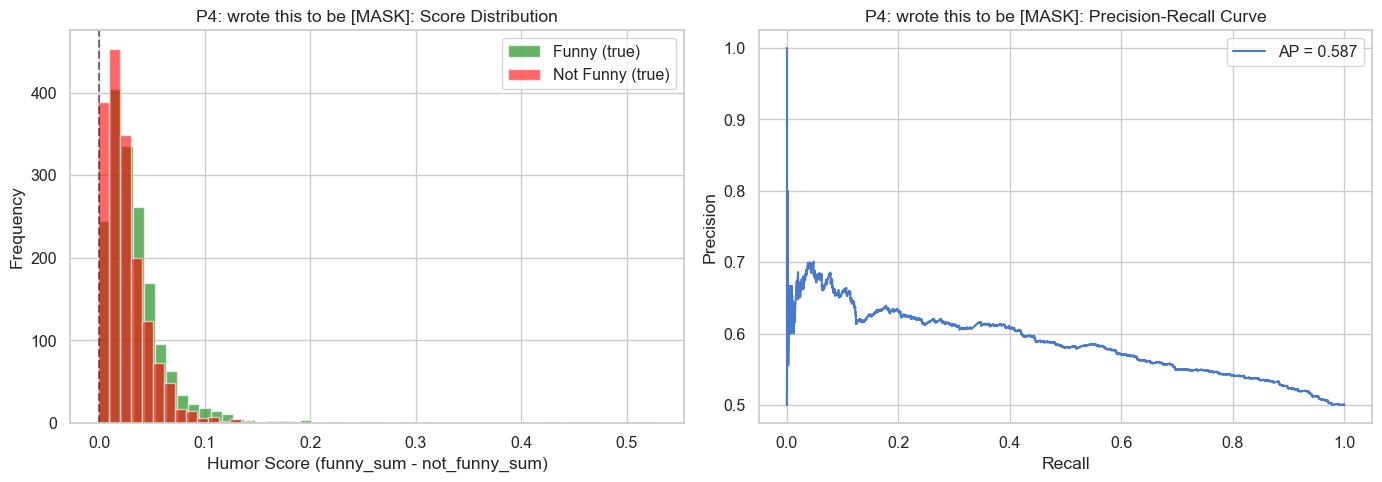

In [ ]:
def evaluate_predictions(results, labels, funny_words, not_funny_words, prompt_name):
    """
    Evaluate how well the BERT predictions correlate with ground truth labels.

    Args:
        results: List of dicts from get_mask_predictions
        labels: Binary labels (0/1) or numeric funny scores
        funny_words: List of words indicating humor
        not_funny_words: List of words indicating lack of humor
        prompt_name: Name of the prompt for display

    Returns:
        Dictionary of evaluation metrics
    """
    # Extract prediction scores
    funny_sums = [r["funny_sum"] for r in results]
    not_funny_sums = [r["not_funny_sum"] for r in results]

    # Calculate humor score: funny_sum - not_funny_sum (or funny_sum / (funny_sum + not_funny_sum))
    humor_scores_diff = [f - nf for f, nf in zip(funny_sums, not_funny_sums)]
    humor_scores_ratio = [
        f / (f + nf + 1e-10) for f, nf in zip(funny_sums, not_funny_sums)
    ]

    # Binary predictions using different thresholds
    binary_preds_diff = [1 if score > 0 else 0 for score in humor_scores_diff]
    binary_preds_ratio = [1 if score > 0.5 else 0 for score in humor_scores_ratio]

    # Compute metrics
    from scipy.stats import spearmanr, pearsonr

    metrics = {
        "prompt": prompt_name,
        # Correlation with labels
        "pearson_diff": pearsonr(humor_scores_diff, labels)[0],
        "spearman_diff": spearmanr(humor_scores_diff, labels)[0],
        "pearson_ratio": pearsonr(humor_scores_ratio, labels)[0],
        "spearman_ratio": spearmanr(humor_scores_ratio, labels)[0],
        # Binary classification metrics (if labels are binary)
        "f1_diff": (
            f1_score(labels, binary_preds_diff) if set(labels) == {0, 1} else None
        ),
        "f1_ratio": (
            f1_score(labels, binary_preds_ratio) if set(labels) == {0, 1} else None
        ),
        # AUC-ROC
        "roc_auc_diff": (
            roc_auc_score(labels, humor_scores_diff) if set(labels) == {0, 1} else None
        ),
        "roc_auc_ratio": (
            roc_auc_score(labels, humor_scores_ratio) if set(labels) == {0, 1} else None
        ),
        # Average precision
        "avg_precision_diff": (
            average_precision_score(labels, humor_scores_diff)
            if set(labels) == {0, 1}
            else None
        ),
        "avg_precision_ratio": (
            average_precision_score(labels, humor_scores_ratio)
            if set(labels) == {0, 1}
            else None
        ),
    }

    return metrics, humor_scores_diff, humor_scores_ratio


def compare_all_prompts(prompts_dict, sample):
    """
    Compare multiple prompts and rank them by performance.

    Args:
        prompts_dict: Dictionary of {prompt_name: (results, funny_words, not_funny_words)}
        sample: DataFrame with labels

    Returns:
        DataFrame with comparison metrics
    """
    all_metrics = []

    # Use binary label
    labels_binary = sample["label_is_funny_binary"].values

    # Or use numeric funny votes (uncomment to use instead)
    # labels_numeric = sample["review_votes_funny"].values

    for prompt_name, (results, funny_words, not_funny_words) in prompts_dict.items():
        metrics, _, _ = evaluate_predictions(
            results, labels_binary, funny_words, not_funny_words, prompt_name
        )
        all_metrics.append(metrics)

    comparison_df = pd.DataFrame(all_metrics)

    # Sort by best correlation or F1 score
    comparison_df = comparison_df.sort_values("roc_auc_ratio", ascending=False)

    return comparison_df


def plot_prediction_distributions(results, labels, prompt_name):
    """
    Plot the distribution of predictions separated by true label.
    """
    funny_sums = np.array([r["funny_sum"] for r in results])
    not_funny_sums = np.array([r["not_funny_sum"] for r in results])
    humor_scores = funny_sums - not_funny_sums

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution by label
    funny_mask = labels == 1
    axes[0].hist(
        humor_scores[funny_mask],
        bins=50,
        alpha=0.6,
        label="Funny (true)",
        color="green",
    )
    axes[0].hist(
        humor_scores[~funny_mask],
        bins=50,
        alpha=0.6,
        label="Not Funny (true)",
        color="red",
    )
    axes[0].set_xlabel("Humor Score (funny_sum - not_funny_sum)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"{prompt_name}: Score Distribution")
    axes[0].legend()
    axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)

    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(labels, humor_scores)
    avg_precision = average_precision_score(labels, humor_scores)
    axes[1].plot(recall, precision, label=f"AP = {avg_precision:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{prompt_name}: Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# Example usage:
# Create a dictionary of all your prompt experiments
prompts_comparison = {
    "P1: This review is [MASK]": (results_p1, funny_words1, not_funny_words1),
    "P2: meant to be [MASK]": (results_p2, funny_words1, not_funny_words1),
    "P3: find this [MASK]": (results_p3, funny_words1, not_funny_words1),
    "P4: wrote this to be [MASK]": (results_p4, funny_words1, not_funny_words1),
    "P5: trying to be [MASK]": (results_p5, funny_words1, not_funny_words1),
    "P6: written in a [MASK] way": (results_p6, funny_words1, not_funny_words1),
    "P7: is [MASK] funny": (results_p7, funny_words7, not_funny_words7),
}

# Compare all prompts
comparison_results = compare_all_prompts(prompts_comparison, sample)
print("\n=== PROMPT COMPARISON ===")
print(comparison_results.to_string(index=False))

# Plot the best performing prompt
best_prompt = comparison_results.iloc[0]["prompt"]
best_results, best_funny, best_not_funny = prompts_comparison[best_prompt]
plot_prediction_distributions(
    best_results, sample["label_is_funny_binary"].values, best_prompt
)